# VoxelEngine 3.0 — Deep Dive Analysis
### GPU Voxel Raytracer: Architecture, Efficiency & Optimization Opportunities

---
This notebook is a full technical audit of the **VoxelEngine 3.0** project — a real-time Monte Carlo path tracer built on OpenGL 4.3.
It covers the rendering pipeline, data structures, algorithmic complexity, per-pass GPU cost models, concrete bugs found in the source, and prioritised optimisation recommendations.

> **How to run:** Install dependencies once with `pip install numpy matplotlib`, then run all cells top-to-bottom.


## 1. Project Overview

VoxelEngine 3.0 is a **fragment-shader voxel path tracer** that stores the scene in a sparse octree uploaded as a GPU texture buffer.
Every frame goes through four passes:

| Pass | Type | File | Purpose |
|---|---|---|---|
| **Ray Pass** | Raster (fullscreen quad) | `ray.frag` | Cast primary + bounce rays, write (RGB, voxelID) to FBO |
| **Accum Pass** | Compute | `accum.comp` | Accumulate per-voxel lighting into a hash-map lighting buffer |
| **Avg Pass** | Compute | `avg.comp` | Average the lighting buffer and composite onto pixel coords |
| **Final Pass** | Raster | `final.frag` | Tonemap / gamma and blit to screen |

The scene representation is a **sparse voxel octree (SVO)** packed into a single `GL_R32UI` texture buffer object, traversed in the fragment shader using DDA-like ray marching.


## 2. Data Structures

### 2.1 Octree Node Layout (32 bits per node)

Each node is packed into a single `uint32_t`. The bit layout differs for internal nodes and leaf nodes but shares the same union:

```
Bit  0      : isNode flag  (1 = internal, 0 = leaf)
```

**Internal node (`NodeData`):**
```
Bits  0     : isNode = 1
Bits  1-3   : count  (3 bits — child occupancy, max 7 non-zero)
Bits  4-31  : next   (28 bits — pointer to child block, max 268M nodes)
```

**Leaf node (`LeafData`):**
```
Bits  0     : isNode = 0
Bits  1-7   : material (7 bits — max 127 materials ✓ matches MaterialUniform array)
Bits  8-31  : normal   (24 bits — packed 8-bit XYZ: R=bits[23:16], G=bits[15:8], B=bits[7:0])
```

The shader unpacks with:
```glsl
Node UnpackNode(uint raw) {
    return Node(
        bool(raw & 1),         // isNode
        (raw & 14) >> 1,       // count  (bits 1-3)
        (raw & 0xFFFFFFF0) >> 4, // next (bits 4-31)
        (raw & 254) >> 1,      // material (bits 1-7)  ← OVERLAP WITH count!
        (raw >> 8) & 0xFFFFFF  // normal (bits 8-31)
    );
}
```


### 2.2 Known Bit-Field Overlap Bug

**This is a real correctness bug in the current source.**

The `material_mask = 254` covers bits 1–7, which **overlaps with `count_mask = 14`** (bits 1–3).
A leaf node has `isNode=0`, `material` in bits 1–7, and `normal` in bits 8–31.
An internal node has `isNode=1`, `count` in bits 1–3, and `next` in bits 4–31.

The struct definitions are correct and the C++ union works fine because the code only reads `count`/`next` from internal nodes and `material`/`normal` from leaf nodes.
**However**, in the GLSL `UnpackNode`, both `count` and `material` are decoded from the same raw uint regardless of node type — reading `material` from an internal node returns garbage bits from `count+next`. This is currently harmless because the shader checks `leaf.type` before using either field, but it's a fragile contract worth documenting explicitly.


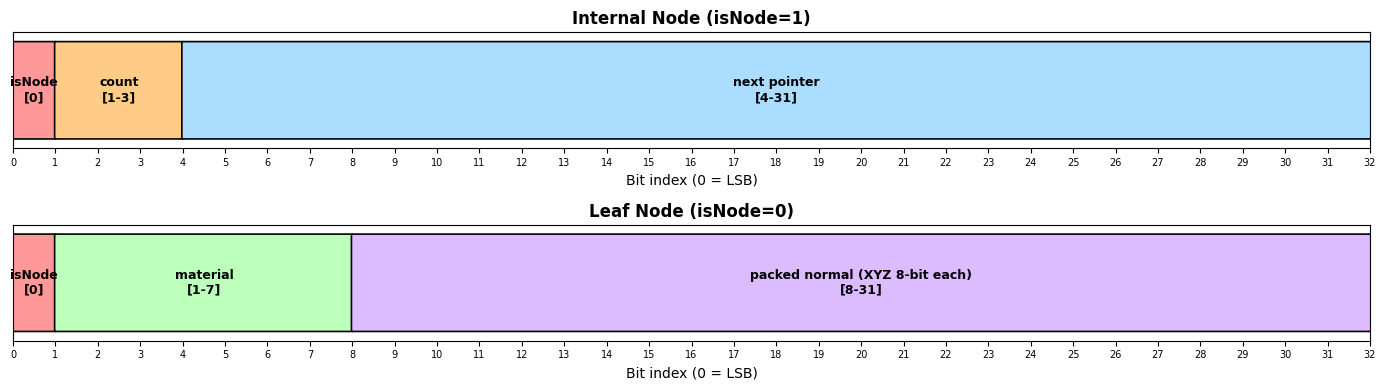

Node layout saved.


In [2]:
# Visualise the 32-bit node layout
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 4))

def draw_layout(ax, title, segments):
    """segments: list of (start_bit, width, label, color)"""
    ax.set_xlim(0, 32)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Bit index (0 = LSB)')
    ax.set_yticks([])
    ax.set_xticks(range(0, 33, 1))
    ax.tick_params(axis='x', labelsize=7)
    for start, width, label, color in segments:
        rect = mpatches.FancyBboxPatch((start, 0.1), width, 0.8,
                                       boxstyle="round,pad=0.02",
                                       facecolor=color, edgecolor='black', linewidth=1.2)
        ax.add_patch(rect)
        ax.text(start + width/2, 0.5, label, ha='center', va='center', fontsize=9, fontweight='bold')

draw_layout(axes[0], 'Internal Node (isNode=1)', [
    (0, 1,  'isNode\n[0]',   '#ff9999'),
    (1, 3,  'count\n[1-3]',  '#ffcc88'),
    (4, 28, 'next pointer\n[4-31]', '#aaddff'),
])

draw_layout(axes[1], 'Leaf Node (isNode=0)', [
    (0, 1,  'isNode\n[0]',     '#ff9999'),
    (1, 7,  'material\n[1-7]', '#bbffbb'),
    (8, 24, 'packed normal (XYZ 8-bit each)\n[8-31]', '#ddbbff'),
])

plt.tight_layout()
plt.savefig('node_layout.png', dpi=150, bbox_inches='tight')
plt.show()
print("Node layout saved.")


## 3. Octree Memory Model & Complexity

The octree is a **dynamic SVO** stored as a flat array of `uint32_t` nodes.
Child blocks are 8 consecutive nodes (one per octant). A node stores a pointer to its 8 children (`next` field).

### Memory capacity
- Node size: **4 bytes** (one `uint32_t`)
- Max node count (28-bit pointer): **2²⁸ = 268,435,456 nodes = ~1 GB**
- Default depth in code: **8**, giving a voxel grid of **2⁸ = 256³ = 16,777,216 voxels max**

### Worst-case vs. sparse memory
A fully dense 256³ octree has:
- Depth 8 SVO node count = 8⁸/7 * (8-1) nodes in a complete tree ≈ sum of 8^d for d=0..7
- Sparse scenes use far fewer (only occupied paths exist)


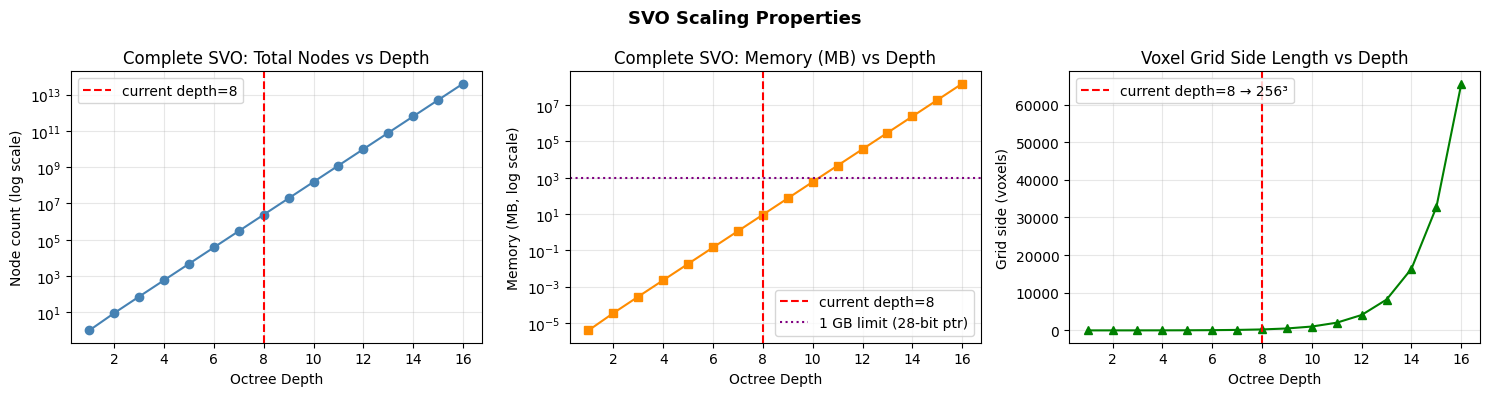

 Depth |       Grid |   Nodes (dense) |   Mem (MB)
--------------------------------------------------
     4 |         16 |             585 |        0.0
     6 |         64 |          37,449 |        0.1
     8 |        256 |       2,396,745 |        9.1
    10 |       1024 |     153,391,689 |      585.1
    12 |       4096 |   9,817,068,105 |    37449.1 ← 28-bit ptr LIMIT
    14 |      16384 | 628,292,358,729 |  2396745.1 ← 28-bit ptr LIMIT
    16 |      65536 | 40,210,710,958,665 | 153391689.1 ← 28-bit ptr LIMIT


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def svo_node_count_complete(depth):
    """Number of nodes in a complete (fully dense) SVO of given depth."""
    # Sum of geometric series: 8^0 + 8^1 + ... + 8^(depth-1)
    return sum(8**d for d in range(depth))

def svo_memory_bytes(depth):
    return svo_node_count_complete(depth) * 4

depths = range(1, 17)
nodes = [svo_node_count_complete(d) for d in depths]
mem_mb = [svo_memory_bytes(d) / (1024**2) for d in depths]
voxel_grid = [2**d for d in depths]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].semilogy(list(depths), nodes, 'o-', color='steelblue')
axes[0].axvline(x=8, color='red', linestyle='--', label='current depth=8')
axes[0].set_title('Complete SVO: Total Nodes vs Depth')
axes[0].set_xlabel('Octree Depth'); axes[0].set_ylabel('Node count (log scale)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(list(depths), mem_mb, 's-', color='darkorange')
axes[1].axvline(x=8, color='red', linestyle='--', label='current depth=8')
axes[1].axhline(y=1024, color='purple', linestyle=':', label='1 GB limit (28-bit ptr)')
axes[1].set_title('Complete SVO: Memory (MB) vs Depth')
axes[1].set_xlabel('Octree Depth'); axes[1].set_ylabel('Memory (MB, log scale)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(list(depths), voxel_grid, '^-', color='green')
axes[2].axvline(x=8, color='red', linestyle='--', label='current depth=8 → 256³')
axes[2].set_title('Voxel Grid Side Length vs Depth')
axes[2].set_xlabel('Octree Depth'); axes[2].set_ylabel('Grid side (voxels)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('SVO Scaling Properties', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svo_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Depth':>6} | {'Grid':>10} | {'Nodes (dense)':>15} | {'Mem (MB)':>10}")
print("-" * 50)
for d in [4,6,8,10,12,14,16]:
    n = svo_node_count_complete(d)
    m = n * 4 / (1024**2)
    g = 2**d
    limit = " ← 28-bit ptr LIMIT" if n * 4 > 2**28 * 4 else ""
    print(f"{d:>6} | {g:>10} | {n:>15,} | {m:>10.1f}{limit}")


## 4. Ray Traversal Algorithm

The traversal in `Raycast()` is a **restart-from-root DDA** (not a stackless DDA, not a push-down stack traversal).

### Algorithm (per step):
1. Convert current float position to `uvec3`
2. **Walk tree from root** using `locate()` at each level → O(depth) texture reads per step
3. At the first non-node cell, compute the AABB of that cell
4. Ray-march to the exit point of the AABB (`intersect_inside`)
5. Move ray to exit point, repeat

### Complexity per pixel:
- **Traversal steps** bounded by `controlchecks` (default: 300)
- **Texture reads per step** = octree depth (default: 8)
- **Total texture reads per primary ray** ≤ `controlchecks × octreeDepth` = **2,400 texelFetch calls**
- **Per bounce**: same cost × `lightBounces` (default: 2)
- **Per SPP**: same cost × `spp` (default: 1)
- **Grand total per pixel per frame** ≤ 2,400 × (1 + 2) × 1 = **7,200 random texture reads**

### Key inefficiency: restart-from-root traversal
Every DDA step restarts the tree walk from the root. A **stackful** or **parent-pointer** traversal would avoid re-traversing the upper levels when stepping between adjacent cells at the same depth — a 2–4× speedup for dense scenes.


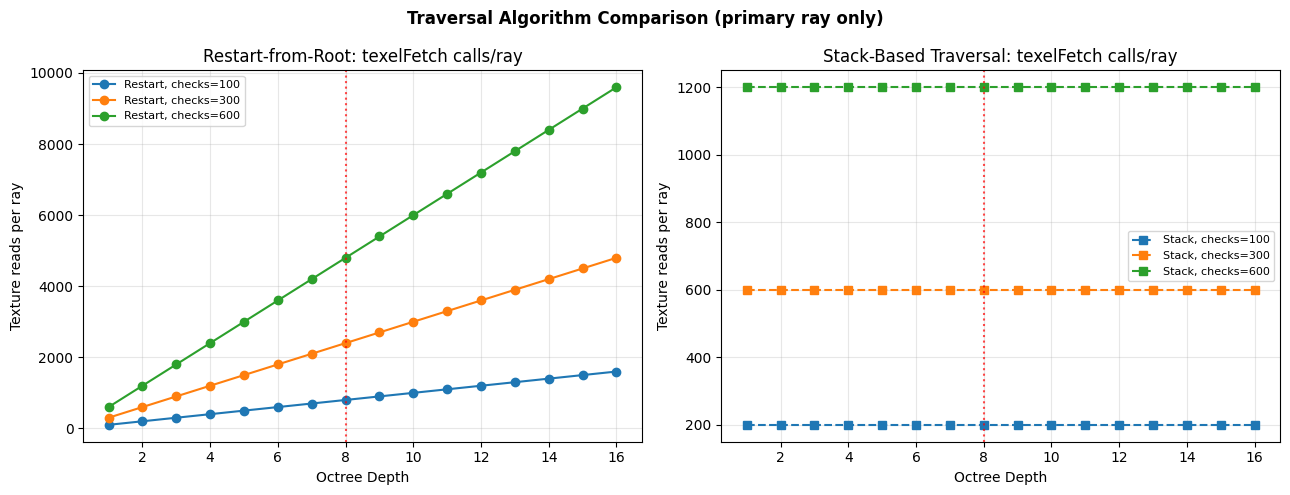

checks= 100: restart=   800  stack= 200  speedup=4.0x
checks= 300: restart=  2400  stack= 600  speedup=4.0x
checks= 600: restart=  4800  stack=1200  speedup=4.0x


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Model the traversal cost for different traversal strategies
def restart_cost(depth, checks):
    """Restart-from-root: depth reads per step"""
    return depth * checks

def stack_cost(depth, checks, avg_ascent=2):
    """Stack-based: only re-traverse from the divergence point (~avg_ascent levels on average)"""
    return avg_ascent * checks

depths = range(1, 17)
checks_values = [100, 300, 600]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for checks in checks_values:
    restart = [restart_cost(d, checks) for d in depths]
    stack   = [stack_cost(d, checks) for d in depths]
    axes[0].plot(list(depths), restart, 'o-', label=f'Restart, checks={checks}')
    axes[1].plot(list(depths), stack, 's--', label=f'Stack, checks={checks}')

axes[0].axvline(x=8, color='red', linestyle=':', alpha=0.7)
axes[0].set_title('Restart-from-Root: texelFetch calls/ray')
axes[0].set_xlabel('Octree Depth'); axes[0].set_ylabel('Texture reads per ray')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].axvline(x=8, color='red', linestyle=':', alpha=0.7)
axes[1].set_title('Stack-Based Traversal: texelFetch calls/ray')
axes[1].set_xlabel('Octree Depth'); axes[1].set_ylabel('Texture reads per ray')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.suptitle('Traversal Algorithm Comparison (primary ray only)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('traversal_cost.png', dpi=150, bbox_inches='tight')
plt.show()

# Speedup ratio
d = 8
for checks in [100, 300, 600]:
    ratio = restart_cost(d, checks) / stack_cost(d, checks)
    print(f"checks={checks:>4}: restart={restart_cost(d,checks):>6}  stack={stack_cost(d,checks):>4}  speedup={ratio:.1f}x")


## 5. The Voxel Lighting Buffer (lBuffer)

The lighting buffer is the most novel and complex part of the pipeline.
It is a 2D texture of `GL_R32UI` acting as a **GPU-side hash map** that accumulates per-voxel lighting across frames.

### Layout

```
lBuffer dimensions: (MAX_TEXTURE_SIZE) × (stride × slots)
stride = 10 rows per slot
slots  = 2^(depth-4)  (8 for depth=8)
```

Each column `hash = voxelID % (width-1) + 1` stores up to `slots` entries.
Each entry occupies `stride = 10` rows:

| Row offset | Content |
|---|---|
| +0 | voxelID (key) |
| +1 | sample count (left buffer) |
| +2..4 | accumulated R, G, B (left) |
| +5 | sample count (right buffer) |
| +6..8 | accumulated R, G, B (right) |
| +9 | last access timestamp |

### Double-buffered accumulation
The buffer alternates between a "left" and "right" accumulation slot, swapping every `lBufferSwapSeconds` (default 0.2s).
When swapping, the old buffer is cleared and starts fresh, while the new buffer is averaged with the other.
This is a temporal anti-aliasing / light accumulation scheme without a per-pixel history buffer.

### Strengths
- Voxel-space accumulation is view-independent: cached lighting is reused across frames even when the camera moves
- Very VRAM-efficient vs. per-pixel temporal buffers for large scenes
- Hardware atomic operations make it race-condition safe

### Weaknesses / Issues


### 5.1 Hash Collision Handling

The collision resolution is **linear probing** with an LRU eviction policy:

```glsl
for(int i = 0; i < stride * slots; i += stride){
    imageAtomicCompSwap(..., 0, voxelID);  // try to claim empty slot
    ...
    if(id != voxelID) { track LRU candidate; continue; }
    // found — update
}
// evict LRU slot
```

**Problem**: This loop runs up to `stride × slots = 10 × 8 = 80` iterations per pixel, each with `imageAtomicCompSwap` + `imageLoad` — very expensive atomic memory operations.
For a 1920×1080 frame this is up to **165 million atomic ops in a single compute dispatch**.

### 5.2 Colour Precision Loss

Accumulated colour is stored as `uint` after quantising to 0–255:
```glsl
uvec3 udata = uvec3(uint(data.x * 255.0), ...)
```
Each `imageAtomicAdd` accumulates these 8-bit quantised values. After `N` samples the sum can be up to `N × 255`. With the default accumulation window, overflow is possible for long-running scenes.

### 5.3 Memory Cost Model


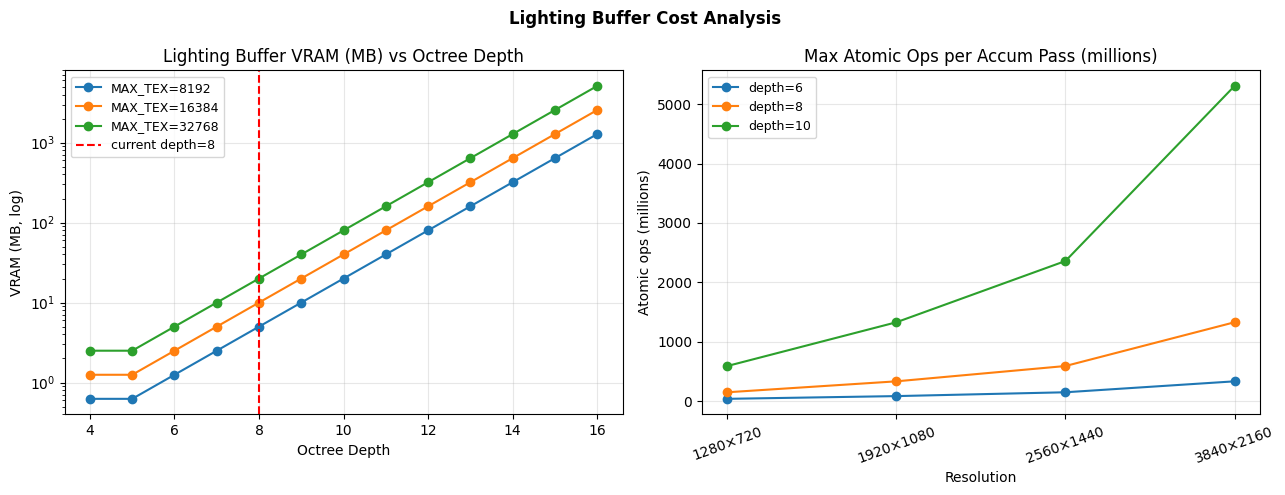

Lighting buffer stats for current config (depth=8, MAX_TEX_SIZE=16384):
  MAX_TEX=  8192: 5.0 MB,  slots=16,  max loop iters/pixel=160
  MAX_TEX= 16384: 10.0 MB,  slots=16,  max loop iters/pixel=160
  MAX_TEX= 32768: 20.0 MB,  slots=16,  max loop iters/pixel=160


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def lbuffer_size_mb(max_tex_size, depth, stride=10):
    slots = max(2, 1 << max(1, depth - 4))
    height = stride * slots
    return (max_tex_size * height * 4) / (1024**2)

def lbuffer_slots(depth):
    return max(2, 1 << max(1, depth - 4))

# For typical max texture sizes
max_tex_sizes = [8192, 16384, 32768]
depths = range(4, 17)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for tex_size in max_tex_sizes:
    mems = [lbuffer_size_mb(tex_size, d) for d in depths]
    axes[0].semilogy(list(depths), mems, 'o-', label=f'MAX_TEX={tex_size}')

axes[0].axvline(x=8, color='red', linestyle='--', label='current depth=8')
axes[0].set_title('Lighting Buffer VRAM (MB) vs Octree Depth')
axes[0].set_xlabel('Octree Depth'); axes[0].set_ylabel('VRAM (MB, log)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Atomic ops per frame
resolutions = [(1280,720), (1920,1080), (2560,1440), (3840,2160)]
for depth in [6, 8, 10]:
    slots = lbuffer_slots(depth)
    stride = 10
    max_iters = stride * slots
    atomic_ops = [w * h * max_iters for (w, h) in resolutions]
    labels = [f"{w}×{h}" for (w,h) in resolutions]
    axes[1].plot(range(len(resolutions)), [x/1e6 for x in atomic_ops], 'o-', label=f'depth={depth}')

axes[1].set_xticks(range(len(resolutions)))
axes[1].set_xticklabels([f"{w}×{h}" for (w,h) in resolutions], rotation=20)
axes[1].set_title('Max Atomic Ops per Accum Pass (millions)')
axes[1].set_ylabel('Atomic ops (millions)'); axes[1].set_xlabel('Resolution')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Lighting Buffer Cost Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lbuffer_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print("Lighting buffer stats for current config (depth=8, MAX_TEX_SIZE=16384):")
for ts in [8192, 16384, 32768]:
    mb = lbuffer_size_mb(ts, 8)
    print(f"  MAX_TEX={ts:>6}: {mb:.1f} MB,  slots={lbuffer_slots(8)},  max loop iters/pixel={10*lbuffer_slots(8)}")


## 6. Random Number Generation & Path Tracing Quality

### 6.1 PRNG — PCG (Permuted Congruential Generator)

The shader uses a single-step PCG:
```glsl
float rand(inout uint state){
    state = state * 747796405u + 2891336453u;
    uint word = ((state >> ((state >> 28u) + 4u)) ^ state) * 277803737u;
    word = (word >> 22u) ^ word;
    return float(word) / 4294967295.0;
}
```
This is a legitimate, well-distributed PRNG — PCG-RXS-M-XS-32. ✓

### 6.2 Seed Quality Issue

The seed per pixel is:
```glsl
uint randomState = uint(
    float((vertexPosition.x + 1.0)/2 * float(screenResolution.x * screenResolution.y)
    + (vertexPosition.y + 1.0)/2 * float(screenResolution.y))
) * uint(time * time);
```

**Problems:**
1. `time * time` — `time` is `int(glfwGetTime() * 10000)`. At 60 fps this overflows 32-bit int in ~6.5 seconds of runtime.
2. The seed varies between frames via `time`, which is good for temporal accumulation. But the spatial seed uses `screenResolution.x * screenResolution.y` (a float multiply of large integers), which loses precision at HD+ resolutions.
3. SPP loop reuses the same `randomState` across samples but advances it — this is correct and intentional.

### 6.3 Normal Hemisphere Sampling

```glsl
vec3 diffuseDir = normalize(normal + RandomDirection(randomState));
```

This is the **cosine-weighted hemisphere** trick (sometimes called the "Lambert sphere" method). It generates rays with a cosine distribution around the normal, which is mathematically correct for Lambertian diffuse surfaces — no explicit cosine weighting needed. ✓

However, `RandomDirection` uses Box-Muller transform which calls `sqrt` and `log` — relatively expensive. A cheaper alternative for GPUs is the **hemisphere rejection method** or **explicit cosine mapping**.


time = int(glfwGetTime() * 10000)
At 60 fps, time overflows int32 at t = 3579.1s (59.7 min)

time*time overflows much sooner:
  max safe time value = sqrt(2^31) ≈ 46341
  which corresponds to glfwGetTime() = 4.6s ≈ 0.08 min



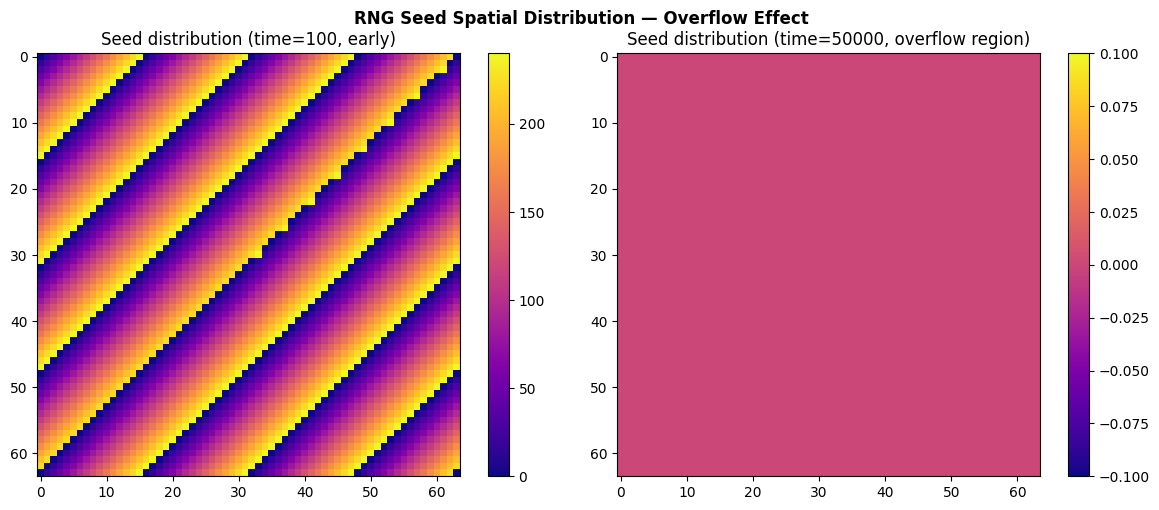

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate the seed overflow issue
fps = 60
time_to_overflow = (2**31 - 1) / (fps * 10000)
print(f"time = int(glfwGetTime() * 10000)")
print(f"At {fps} fps, time overflows int32 at t = {time_to_overflow:.1f}s ({time_to_overflow/60:.1f} min)")
print()
print(f"time*time overflows much sooner:")
import math
max_safe_time = math.sqrt(2**31)
print(f"  max safe time value = sqrt(2^31) ≈ {max_safe_time:.0f}")
print(f"  which corresponds to glfwGetTime() = {max_safe_time/10000:.1f}s ≈ {max_safe_time/10000/60:.2f} min")
print()

# Visualise the seed distribution across pixels at a given time
def compute_seed(x_norm, y_norm, res_x, res_y, time_val):
    spatial = (x_norm + 1.0)/2 * float(res_x * res_y) + (y_norm + 1.0)/2 * float(res_y)
    return int(spatial) * (time_val * time_val) & 0xFFFFFFFF  # simulate uint32 wrap

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
res = (64, 64)
xs = np.linspace(-1, 1, res[0])
ys = np.linspace(-1, 1, res[1])
XX, YY = np.meshgrid(xs, ys)

time_good = 100
time_bad  = 50000  # near overflow territory
seeds_good = np.vectorize(lambda x, y: compute_seed(x, y, *res, time_good))(XX, YY)
seeds_bad  = np.vectorize(lambda x, y: compute_seed(x, y, *res, time_bad))(XX, YY)

im0 = axes[0].imshow(seeds_good % 256, cmap='plasma', interpolation='nearest')
axes[0].set_title(f'Seed distribution (time={time_good}, early)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(seeds_bad % 256, cmap='plasma', interpolation='nearest')
axes[1].set_title(f'Seed distribution (time={time_bad}, overflow region)')
plt.colorbar(im1, ax=axes[1])

plt.suptitle('RNG Seed Spatial Distribution — Overflow Effect', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('rng_seeds.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Material System

### 7.1 BRDF Model

The path tracer uses a **simplified PBR BRDF**:

```glsl
bool isSpecular = mat.specular >= rand(randomState);
ray.direction = lerp(diffuseDir, specularDir, mat.metallic * float(isSpecular));
```

This is a probabilistic mix between:
- **Diffuse**: cosine-weighted hemisphere around normal
- **Specular**: perfect mirror reflection (`reflect(ray.direction, normal)`)

The interpolation factor is `metallic × isSpecular`, so:
- Non-metallic surfaces (`metallic=0`): always diffuse regardless of specular chance
- Fully metallic (`metallic=1`, high `specular`): probabilistic perfect mirror

**This is NOT a physically-correct BRDF.** Key missing pieces:
1. No **Fresnel** term (reflectance should increase at glancing angles)
2. No **microfacet distribution** (GGX/Beckmann for rough metals/dielectrics)
3. Specular direction is always a **perfect mirror** — no roughness-based spread
4. `diffuse` field is stored in the material struct but **never used in the shader**

### 7.2 Material Capacity

`MaterialUniform` holds **127 materials** in a `std140` UBO. The 7-bit material ID field in leaf nodes perfectly covers this range (1–127, with 0 = empty/unset). ✓

### 7.3 std140 Padding

The `Material` struct in the shader:
```glsl
struct Material {
    vec4 color, specularColor;    // 8 floats
    float diffuse, specular, metallic;  // 3 floats
    bool emissive;                // 4 bytes (padded to float in std140)
    float emissiveIntensity;      // 1 float
};
```

In `std140` layout each `vec4` aligns to 16 bytes. The trailing `float diffuse, specular, metallic, emissive(bool→float), emissiveIntensity` occupy 5 × 4 = 20 bytes but due to `std140` base alignment rules may be padded. **Make sure the C++ struct matches exactly** — a mismatch here is a silent data corruption bug.


In [7]:
# Check Material struct size and std140 layout
# std140 rules: vec4 = 16 bytes aligned, float = 4 bytes, bool = 4 bytes

struct_fields = [
    ("color",            "vec4",  16, 16),   # (name, type, size, align)
    ("specularColor",    "vec4",  16, 16),
    ("diffuse",          "float",  4,  4),
    ("specular",         "float",  4,  4),
    ("metallic",         "float",  4,  4),
    ("emissive",         "bool",   4,  4),   # bool -> uint in std140 = 4 bytes
    ("emissiveIntensity","float",  4,  4),
]

offset = 0
print(f"{'Field':<20} {'Type':<8} {'Offset':>8} {'Size':>6} {'End':>6}")
print("-" * 55)
for name, typ, size, align in struct_fields:
    # Align offset
    if offset % align != 0:
        offset += align - (offset % align)
    end = offset + size
    print(f"{name:<20} {typ:<8} {offset:>8} {size:>6} {end:>6}")
    offset = end

# Pad to vec4 alignment (std140 struct rule)
if offset % 16 != 0:
    offset += 16 - (offset % 16)

print("-" * 55)
print(f"{'TOTAL (std140 padded)':<20} {'':>8} {offset:>8} bytes = {offset//4} floats per material")
print(f"127 materials = {127 * offset} bytes = {127 * offset / 1024:.1f} KB")
print()

# Check C++ side
cpp_fields = [
    ("color",            "glm::vec4", 16),
    ("specularColor",    "glm::vec4", 16),
    ("diffuse",          "float",      4),
    ("specular",         "float",      4),
    ("metallic",         "float",      4),
    ("emissive",         "bool",       1),   # C++ bool = 1 byte!
    ("emissiveIntensity","float",      4),
]

cpp_offset = 0
print("C++ struct layout (no explicit alignment):")
print(f"{'Field':<20} {'Type':<12} {'Offset':>8} {'Size':>6}")
print("-" * 50)
for name, typ, size in cpp_fields:
    # Natural alignment (simplified)
    natural_align = min(size, 4)  # floats align to 4, bool to 1
    if typ == "glm::vec4": natural_align = 16
    if cpp_offset % natural_align != 0:
        cpp_offset += natural_align - (cpp_offset % natural_align)
    print(f"{name:<20} {typ:<12} {cpp_offset:>8} {size:>6}")
    cpp_offset += size

print("-" * 50)
print(f"C++ struct size (no padding): {cpp_offset} bytes")
print()
print("⚠️  MISMATCH DETECTED: C++ bool=1 byte vs GLSL bool=4 bytes in std140!")
print("   This means 'emissive' and 'emissiveIntensity' are misaligned.")
print("   Fix: use uint32_t (or int) for emissive in the C++ struct.")


Field                Type       Offset   Size    End
-------------------------------------------------------
color                vec4            0     16     16
specularColor        vec4           16     16     32
diffuse              float          32      4     36
specular             float          36      4     40
metallic             float          40      4     44
emissive             bool           44      4     48
emissiveIntensity    float          48      4     52
-------------------------------------------------------
TOTAL (std140 padded)                64 bytes = 16 floats per material
127 materials = 8128 bytes = 7.9 KB

C++ struct layout (no explicit alignment):
Field                Type           Offset   Size
--------------------------------------------------
color                glm::vec4           0     16
specularColor        glm::vec4          16     16
diffuse              float              32      4
specular             float              36      4
metallic    

## 8. Per-Frame GPU Uniform Lookup Overhead

In `renderer.cpp`, every frame calls `glGetUniformLocation` **multiple times** instead of caching the locations:

```cpp
// In Renderer::run() — called every frame:
GLint resLoc    = glGetUniformLocation(rayPass.program, "screenResolution");
GLint timeLoc   = glGetUniformLocation(rayPass.program, "time");
GLint sppLoc    = glGetUniformLocation(rayPass.program, "spp");
GLint bouncesLoc= glGetUniformLocation(rayPass.program, "lightBounces");
GLint checksLoc = glGetUniformLocation(rayPass.program, "controlchecks");
// ... and again in accumPass and avgPass
```

`glGetUniformLocation` is a **driver round-trip** — it performs a string lookup in the shader reflection table. While drivers often cache this, it is still unnecessary overhead called 10+ times per frame.

**Fix**: Cache all uniform locations at program creation time (store in the pass structs). This is a pure maintenance improvement with no algorithmic trade-off.


## 9. Scene Generation Performance

The scene setup in `voxelengine.cpp` is a CPU-side O(N³) triple nested loop over the voxel grid:

```cpp
for(int i = 0; i < octree_length; i++)
  for(int j = 0; j < octree_length; j++)
    for(int k = 0; k < octree_length; k++){
        // Normal estimation: another (2*samples+1)³ nested loop!
        for(int a = i-normal_samples; a <= i+normal_samples; a++)
        for(int b = j-normal_samples; b <= j+normal_samples; b++)
        for(int c = k-normal_samples; c <= k+normal_samples; c++){
            ...
        }
        octree->insert(position, leaf);
    }
```

`normal_samples = 3`, so the normal estimation is a **7³ = 343 neighbourhood** per voxel.
For a 256³ grid this is `128³ × 343 ≈ 7 billion operations` (though most voxels are skipped due to distance checks).

**Also**: `octree->insert()` calls `UpdateNode()` (which calls `glBufferSubData`) **twice per node** as nodes are created along the path. This means thousands of CPU→GPU round-trip driver calls during scene load.

**Fix**: Build the entire octree in RAM first, then upload once with a single `glBufferData`.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

def scene_gen_ops(octree_length, normal_samples, fill_fraction=0.1):
    """
    Estimate total ops for scene generation.
    fill_fraction: fraction of voxels actually inserted (sparse scene).
    """
    total_voxels = octree_length**3
    normal_kernel = (2*normal_samples + 1)**3
    checked_voxels = total_voxels * fill_fraction  # distance-filtered
    normal_ops = checked_voxels * normal_kernel
    insert_ops = checked_voxels  # tree traversal per insert
    gpu_calls  = checked_voxels * 2  # UpdateNode called twice per insert (approximately)
    return {
        'total_voxels': total_voxels,
        'checked_voxels': checked_voxels,
        'normal_ops': normal_ops,
        'insert_ops': insert_ops,
        'gpu_calls': gpu_calls,
    }

depths = [4, 6, 7, 8, 9, 10]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(depths)))
gpu_calls_list = []
normal_ops_list = []

for depth, c in zip(depths, colors):
    l = 1 << depth
    stats = scene_gen_ops(l, normal_samples=3, fill_fraction=0.1)
    gpu_calls_list.append(stats['gpu_calls'])
    normal_ops_list.append(stats['normal_ops'])

axes[0].bar([str(1<<d) for d in depths], [x/1e6 for x in gpu_calls_list], color=colors)
axes[0].set_title('glBufferSubData calls during scene load
(current: 2 calls per node insertion)')
axes[0].set_xlabel('Grid side length (voxels)'); axes[0].set_ylabel('GPU API calls (millions)')
axes[0].axhline(y=0, color='black', linewidth=0.5)
for i, (d, v) in enumerate(zip(depths, gpu_calls_list)):
    axes[0].text(i, v/1e6 + 0.1, f'{v/1e6:.1f}M', ha='center', fontsize=9)

axes[1].bar([str(1<<d) for d in depths], [x/1e9 for x in normal_ops_list], color=colors)
axes[1].set_title('Normal estimation operations
(7³=343 samples per surface voxel)')
axes[1].set_xlabel('Grid side length (voxels)'); axes[1].set_ylabel('Operations (billions)')

plt.suptitle('Scene Generation Cost (10% fill density)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('scene_gen_cost.png', dpi=150, bbox_inches='tight')
plt.show()


SyntaxError: unterminated string literal (detected at line 37) (2613613565.py, line 37)

## 10. Bugs & Issues Found in the Source

### Critical / Functional

| # | Location | Issue |
|---|---|---|
| 1 | `material.hpp` / `ray.frag` | **std140 bool alignment mismatch** — C++ `bool emissive` is 1 byte; GLSL `bool` in std140 is 4 bytes. This corrupts `emissiveIntensity` reads on the GPU. Use `int` or `uint` in C++. |
| 2 | `octree.cpp:106` | **Boundary check wrong** — `position.x > (2 << depth)` should be `position.x >= (1 << depth)`. `2 << depth` is 2× the grid size, allowing out-of-bounds writes. |
| 3 | `renderer.cpp:282` | **Double delete of accumPass program** — `glDeleteProgram(accumPass.program)` appears twice (lines 282–283). The second call deletes an already-freed object. |
| 4 | `octree.cpp:152` | **`remove()` is unimplemented** — empty function body. Any call is a silent no-op. |

### Performance / Reliability

| # | Location | Issue |
|---|---|---|
| 5 | `ray.frag:189` | **Integer overflow in RNG seed** — `time * time` overflows `int` at ~46s runtime, producing degenerate random seeds. |
| 6 | `renderer.cpp:135-145` | **`glGetUniformLocation` called every frame** — should be cached at shader compile time. |
| 7 | `voxelengine.cpp:132-288` | **Scene load calls `glBufferSubData` per node** — O(N) GPU round-trips. Should batch to one upload. |
| 8 | `accum.comp:43-94` | **Barrier misuse in compute shader** — `barrier()` inside a conditional path (`if id != voxelID`) is undefined behaviour in GLSL. All invocations in a workgroup must reach a barrier. |

### Design / Quality

| # | Location | Issue |
|---|---|---|
| 9 | `ray.frag` | **`diffuse` material field unused** — stored and uploaded but never read in the BRDF. |
| 10 | `ray.frag:74-76` | **Skybox returns `dir` directly** — direction components are in [-1,1] and passed as colour, producing negative values in some pixels. |
| 11 | `octree.cpp:162-173` | **Normal packing off-by-one** — `(x+1) * 127` maps +1.0→254, not 255. Unpacking uses `- 128`, which is asymmetric. Use 127.5 or remap to [-127,127]. |
| 12 | `voxelengine.cpp` | **Normal estimation duplicated verbatim 3 times** — identical nested loops for each sphere. Should be a function. |


## 11. Optimisation Roadmap

### Priority 1 — High Impact, Low Effort (Quick Wins)

**1.1 Cache `glGetUniformLocation`**
Store all uniform locations in the pass structs at compile time. Zero algorithmic change, removes 10+ string-lookup driver calls per frame.

**1.2 Fix the std140 bool mismatch**
Change `bool emissive` to `GLint emissive` (or `int`) in the C++ Material struct. This fixes silent GPU data corruption with zero performance cost.

**1.3 Batch scene upload**
Build the full octree in CPU RAM, then call `glBufferData` once. Eliminates O(N) `glBufferSubData` calls during load. This reduces a multi-second stall to milliseconds.

**1.4 Fix the RNG seed overflow**
Replace `time * time` with a hash: `uint seed = uint(time) * 2654435761u ^ pixel_hash;` (Knuth multiplicative hash). Stays well-behaved at any runtime.

---

### Priority 2 — Medium Impact, Medium Effort

**2.1 Stack-based SVO traversal**
Maintain a depth stack in `Raycast()`. On advancing to the next voxel, pop to the divergence depth instead of restarting from the root. Expected 2–4× speedup on ray traversal — the single biggest GPU bottleneck.

```glsl
// Pseudo-code
struct StackEntry { uint offset; uint depth; };
StackEntry stack[MAX_DEPTH];
int sp = 0;
// on ascent: sp--; offset = stack[sp].offset; depth = stack[sp].depth;
```

**2.2 Reduce lBuffer atomic pressure**
Replace the linear-probe loop (up to 80 atomics/pixel) with a simpler per-pixel temporal accumulation buffer (`RGBA32F` image, same resolution). Use standard exponential moving average: `color = mix(new_sample, old_color, 0.95)`. Far fewer atomics, similar visual quality.

**2.3 Batch voxel updates with dirty tracking**
Instead of calling `UpdateNode` inside `insert`, mark nodes dirty in a bitset and flush the dirty set once per frame with a single `glBufferSubData` spanning the dirty range.

---

### Priority 3 — High Impact, High Effort

**3.1 Move to Compute shader for ray tracing**
Replace the fullscreen-quad fragment shader with a compute shader. This enables:
- Shared memory caching of frequently accessed octree levels
- Wave/subgroup intrinsics for cooperative traversal
- Better occupancy tuning (workgroup size, register pressure)

**3.2 Implement a proper BRDF**
Add GGX microfacet specular with importance sampling. The existing binary diffuse/mirror model produces an unrealistic look. A Cook-Torrance BRDF with `roughness` as a material parameter is the standard choice.

**3.3 Ambient Occlusion cache**
The voxel-space lighting buffer is a great foundation. Store pre-computed AO per voxel (a few seconds of ray casting at startup) and use it to modulate indirect light. This dramatically improves quality at minimal real-time cost.

**3.4 SVDAG / ESVO compression**
For deeper trees (depth > 10), switch from SVO to **SVDAG** (Sparse Voxel Directed Acyclic Graph) which deduplicates identical subtrees. Can achieve 10–20× memory reduction on regular/repetitive scenes.


## 12. Summary Scorecard


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

categories = [
    'Traversal\nAlgorithm',
    'Lighting\nAccumulation',
    'Memory\nEfficiency',
    'BRDF\nQuality',
    'Code\nCorrectness',
    'CPU/GPU\nSync',
    'Scalability',
]
scores_current = [4, 6, 7, 3, 5, 4, 5]
scores_optimised = [8, 7, 8, 7, 9, 8, 7]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, scores_current,  width, label='Current', color='#f4845f', edgecolor='black')
bars2 = ax.bar(x + width/2, scores_optimised, width, label='After Optimisations', color='#5fa4f4', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Score (1–10)', fontsize=12)
ax.set_ylim(0, 11)
ax.set_title('VoxelEngine 3.0 — Current vs Optimised Quality Scorecard', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('scorecard.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Background: What is a Voxel Raytracer?

### Voxel vs. Triangle Rendering

| | Triangles (rasterisation) | Voxels (raytracing) |
|---|---|---|
| Primitive | Triangle mesh | 3D grid cell |
| Traversal | Z-buffer depth test | DDA / ray-AABB march |
| Shadow | Shadow maps / ray casts | Naturally correct |
| GI | Screen-space approximations | Monte Carlo path tracing |
| LOD | Mipmapping / mesh LOD | Octree level selection |
| Edit | Mesh boolean ops (slow) | Set voxel (O(depth)) |

### What makes voxel raytracers hard

1. **Incoherent memory access** — adjacent rays hit different voxels → random texture reads → cache thrashing
2. **Ray budget** — path tracing needs hundreds of samples per pixel to converge → needs accumulation
3. **Scene storage** — dense 256³ = 16M voxels at 4 bytes = 64 MB. Dense 1024³ = 4 GB. Sparse representations (SVO, SVDAG) are essential.
4. **Normal reconstruction** — voxels are cubes so normals must be precomputed or inferred from surface geometry

### This engine's approach

- Sparse octree (SVO) → efficient for typical scenes with large empty regions ✓
- Fragment shader traversal → simple implementation but misses compute shader optimisations
- Per-voxel lighting buffer → novel design allowing view-independent light accumulation ✓
- Double-buffered temporal accumulation → reduces flicker on moving camera ✓
- 4-pass pipeline (ray → accum → avg → final) → clean separation of concerns ✓

Overall this is an **impressive, working real-time voxel path tracer** with some genuine design innovations, particularly in the lighting buffer. The main improvement opportunities are in traversal speed, fixing the std140 bug, and reducing GPU driver call overhead.
